# 02 — Imagen → Radon → sinograma

## Objetivo

Comprender la orientación y el muestreo de las proyecciones utilizadas en el Hito 1.

**Alcance:** Hito 1 actualizado.

## Datos utilizados

Par TCIA C095/1-250 de `config/default.json`. Las rutas DICOM se configuran en ese JSON; por defecto se usan data/sdct y data/ldct. Cada notebook se ejecuta de forma independiente.

## Procedimiento

Proyectar las dos entradas normalizadas con los mismos 512 ángulos en [0°,180°), circle=False y preserve_range=True.

**Procedencia:** ldct/sinogram.py: generate_sinogram; sdct_ldct_sinograma_gaussiano.ipynb, celda 16; detalles en `../REFACTOR_MAP.md`.

## Parámetros

In [1]:
from pathlib import Path
import os
import sys
sys.dont_write_bytecode = True
start = Path.cwd().resolve()
root = next((p for p in (start, *start.parents) if (p / 'src/config.py').is_file() and (p / 'config/default.json').is_file()), None)
if root is None and (start / 'hito1-mini-tesis/src').is_dir():
    root = start / 'hito1-mini-tesis'
if root is None:
    raise RuntimeError('Abre Jupyter desde la raíz del repositorio o su carpeta notebooks.')
sys.path.insert(0, str(root))
os.environ['MPLCONFIGDIR'] = str(root / 'outputs/.matplotlib')
import matplotlib.pyplot as plt
from src.config import load_config, output_path
from src.experiments import prepare_pair
from src.visualization import show_table, finish_figure
config = load_config()
show_table([{key: config[key] for key in ('num_angles', 'sigma_gaussian', 'seed', 'filter_name', 'visual_amplification')}])

num_angles,sigma_gaussian,seed,filter_name,visual_amplification
512,1,42,ramp,5


## Resultados

imagen,detectores,angulos,paso_angular_grados
SDCT,725,512,0.351562
LDCT,725,512,0.351562


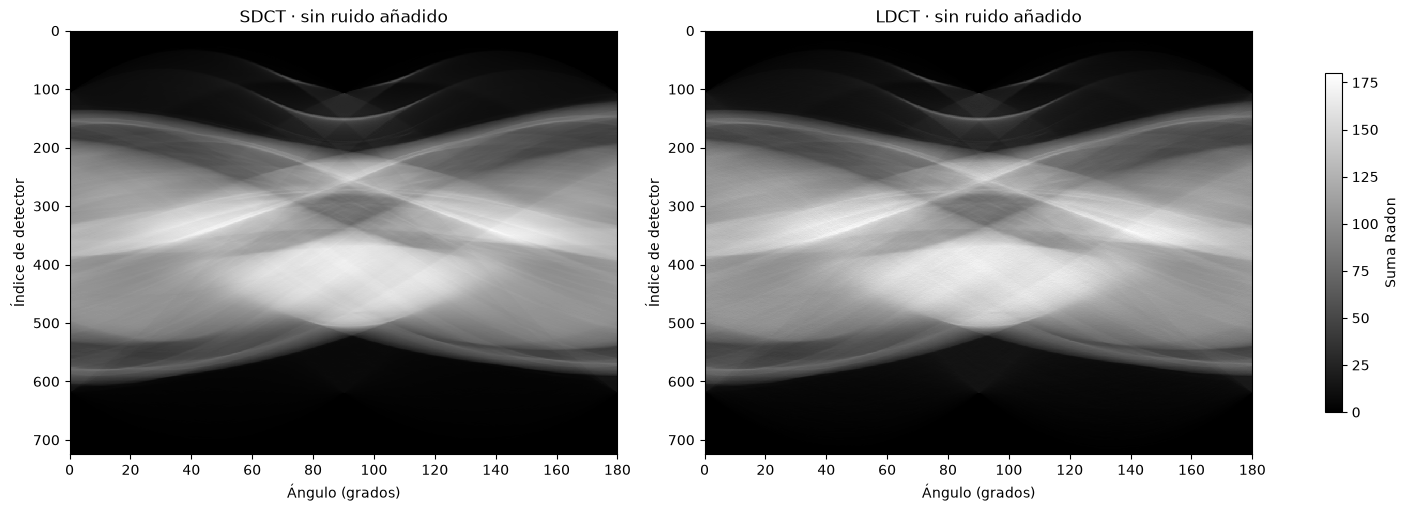

In [2]:
from src.radon import generate_sinogram
from src.visualization import plot_sinograms
pair = prepare_pair(config)
sinograms = [generate_sinogram(pair[key], pair['theta']) for key in ('sdct', 'ldct')]
show_table([{'imagen': name, 'detectores': sino.shape[0], 'angulos': sino.shape[1],
             'paso_angular_grados': 180 / len(pair['theta'])} for name, sino in zip(('SDCT', 'LDCT'), sinograms)])
fig = plot_sinograms(sinograms, ['SDCT · sin ruido añadido', 'LDCT · sin ruido añadido'])
finish_figure(fig, output_path('figures', '02_sinograms.png'))

Cada columna es una proyección. Estas son sumas en unidades de píxel normalizado: no son sinogramas originales del escáner ni integrales calibradas de atenuación.

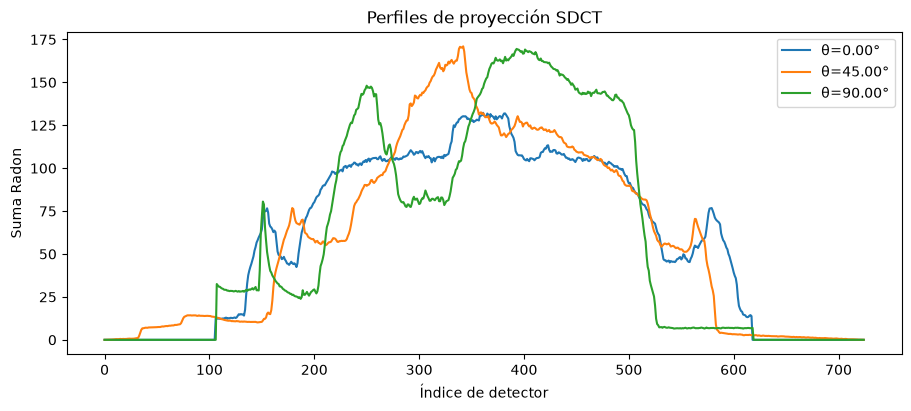

In [3]:
indices = [0, len(pair['theta']) // 4, len(pair['theta']) // 2]
fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')
for index in indices:
    ax.plot(sinograms[0][:, index], label=f"θ={pair['theta'][index]:.2f}°")
ax.set(xlabel='Índice de detector', ylabel='Suma Radon', title='Perfiles de proyección SDCT')
ax.legend()
finish_figure(fig, output_path('figures', '02_projection_profiles.png'))

## Observaciones

La forma es (725 detectores, 512 ángulos) en el caso de referencia. circle=False conserva el campo completo, incluida la camilla. Los perfiles son una lectura del mismo sinograma, sin una adquisición adicional.